In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
career_df = pd.read_csv('career_it_recomendation.csv')

career_df.head()

,jenis_kelamin,jurusan_s1,spesialisasi_s1,minat,keterampilan,judul_sertifikasi,pekerjaan_pertama,ipk_s1,profil_lengkap
0,Female,Sarjana Sains,Aplikasi Komputer,Cloud Computing,Java; Python; SQL,"Linux,Git",Software,3.40,Sarjana Sains | Aplikasi Komputer | Cloud Comp...
1,Male,Sarjana Teknik,Teknik Informatika,Teknologi,Berpikir Analitis; Berpikir Kritis; Kerja di B...,Microsoft Certification,Computer Software Engineer,2.66,Sarjana Teknik | Teknik Informatika | Technolo...
2,Female,Sarjana Teknik,Teknik Informatika,Teknologi,C++; HTML; Java,"C,C++,Html,Java",Analis Jaringan,2.93,Sarjana Teknik | Teknik Informatika | Technolo...
3,Male,Sarjana Teknik,Teknik Informatika,Teknologi,Tidak Tersedia,No,Software Engineer Trainee,2.96,Sarjana Teknik | Teknik Informatika | Technolo...
4,Male,Sarjana Teknik,Teknik Informatika,Teknologi,Berpikir Kritis; Java; Linux; Pemrograman; Pyt...,Redhat Certification,Senior Software Engineer,2.77,Sarjana Teknik | Teknik Informatika | Technolo...


In [4]:
remove_jobs = [
    "Tidak Tersedia",
    "Mahasiswa (Belum Bekerja)"
]

career_df = career_df[
    ~career_df['pekerjaan_pertama'].isin(remove_jobs)
].copy()

# 3. DATA SET OVERVIEW

In [5]:
career_df.shape

(227, 9)

In [6]:
career_df.info()

<class 'pandas.DataFrame'>
Index: 227 entries, 0 to 354
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   jenis_kelamin      227 non-null    str    
 1   jurusan_s1         227 non-null    str    
 2   spesialisasi_s1    227 non-null    str    
 3   minat              227 non-null    str    
 4   keterampilan       227 non-null    str    
 5   judul_sertifikasi  227 non-null    str    
 6   pekerjaan_pertama  227 non-null    str    
 7   ipk_s1             227 non-null    float64
 8   profil_lengkap     227 non-null    str    
dtypes: float64(1), str(8)
memory usage: 119.9 KB


In [7]:
career_df.describe(include='all')

,jenis_kelamin,jurusan_s1,spesialisasi_s1,minat,keterampilan,judul_sertifikasi,pekerjaan_pertama,ipk_s1,profil_lengkap
count,227,227,227,227,227,227,227,227.000000,227
unique,3,12,35,142,206,121,144,NaN,226
top,Male,Sarjana Teknik,Teknik Informatika,Teknologi,Tidak Tersedia,No,Computer Software Engineer,NaN,Sarjana Teknik | Teknik Informatika | Software...
freq,156,173,117,38,12,100,13,NaN,2
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.889031,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.373159,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.870000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.660000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.940000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.140000,NaN


## Dataset Overview

Dataset career IT recommendation berisi profil akademik, minat, keterampilan, sertifikasi, dan pekerjaan pertama pengguna pada bidang teknologi informasi. Dataset ini akan digunakan untuk membangun sistem rekomendasi karir berbasis AI.

# 4. CHECK MISSING VALUE & DUPLICATE

In [8]:
career_df.isnull().sum()

jenis_kelamin        0
jurusan_s1           0
spesialisasi_s1      0
minat                0
keterampilan         0
judul_sertifikasi    0
pekerjaan_pertama    0
ipk_s1               0
profil_lengkap       0
dtype: int64

In [9]:
career_df = career_df.drop_duplicates().copy()

In [10]:
career_df.duplicated().sum()

np.int64(0)

# Data Quality Checking

Tahap ini dilakukan untuk memastikan dataset tidak memiliki missing value maupun data duplikat yang dapat memengaruhi performa model machine learning.

In [11]:
career_df.columns

Index(['jenis_kelamin', 'jurusan_s1', 'spesialisasi_s1', 'minat',
       'keterampilan', 'judul_sertifikasi', 'pekerjaan_pertama', 'ipk_s1',
       'profil_lengkap'],
      dtype='str')

# 6. DISTRIBUSI PEKERJAAN

In [12]:
top_jobs = career_df['pekerjaan_pertama'].value_counts().head(10)

top_jobs

pekerjaan_pertama
Computer Software Engineer     13
Data Analyst                   11
Software Engineer              10
Software Developer              8
Associate Consultant            8
Data Scientist                  5
Cyber Security Analyst          4
Business Analyst                4
Production Engineer             3
Associate Software Engineer     3
Name: count, dtype: int64

In [13]:
remove_jobs = [
    "Tidak Tersedia",
    "Mahasiswa (Belum Bekerja)"
]

career_df = career_df[
    ~career_df['pekerjaan_pertama'].isin(remove_jobs)
].copy()

In [14]:
career_df['pekerjaan_pertama'].value_counts()

pekerjaan_pertama
Computer Software Engineer    13
Data Analyst                  11
Software Engineer             10
Software Developer             8
Associate Consultant           8
                              ..
Placement Trainee              1
Miritary Soldier               1
Salesforce Admin               1
Cloud Engineer                 1
Sistem Informasi Manajemen     1
Name: count, Length: 144, dtype: int64

In [15]:
career_df['pekerjaan_pertama'].value_counts().head(10)

pekerjaan_pertama
Computer Software Engineer     13
Data Analyst                   11
Software Engineer              10
Software Developer              8
Associate Consultant            8
Data Scientist                  5
Cyber Security Analyst          4
Business Analyst                4
Production Engineer             3
Associate Software Engineer     3
Name: count, dtype: int64

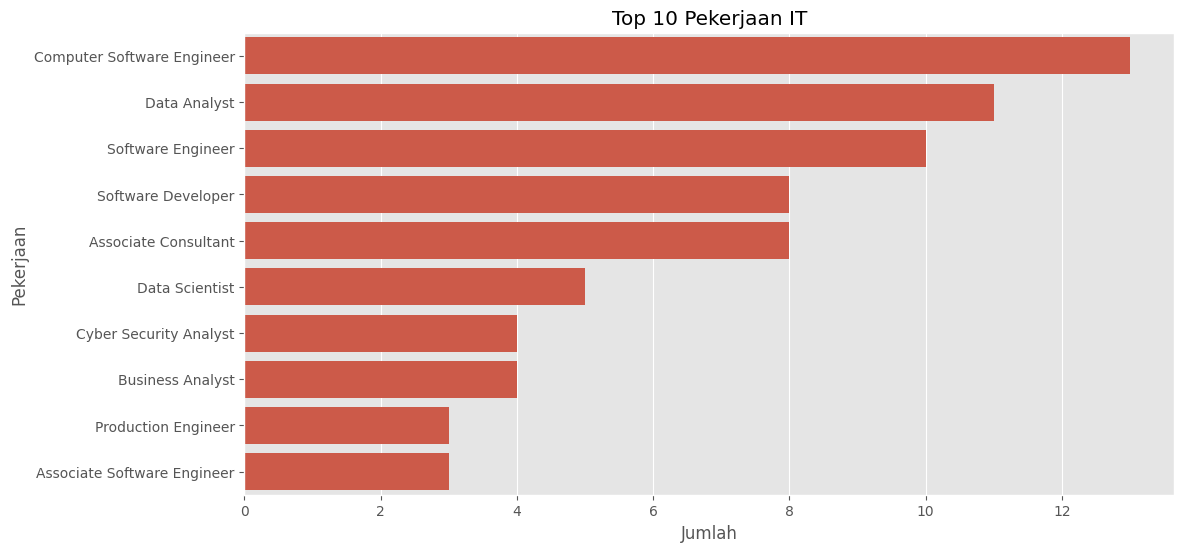

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index
)

plt.title("Top 10 Pekerjaan IT")
plt.xlabel("Jumlah")
plt.ylabel("Pekerjaan")

plt.show()

### Insight Distribusi Pekerjaan

Beberapa pekerjaan IT memiliki jumlah data yang lebih dominan dibanding pekerjaan lainnya. Hal ini menunjukkan bahwa distribusi kelas pada dataset belum sepenuhnya seimbang sehingga perlu dilakukan filtering atau balancing pada tahap modeling.

Ditemukan beberapa label pekerjaan yang tidak representatif seperti "Tidak Tersedia" dan "Mahasiswa (Belum Bekerja)". Label tersebut dihapus pada tahap preprocessing karena tidak merepresentasikan target pekerjaan yang valid untuk sistem rekomendasi karir.

# 7. DISTRIBUSI JURUSAN

In [17]:
top_major = career_df['jurusan_s1'].value_counts().head(10)

top_major

jurusan_s1
Sarjana Teknik                  172
Sarjana Sains                    19
Sarjana Ekonomi                  11
Sarjana Komputer                  7
Magister Komputer                 5
M.Tech                            4
Magister Administrasi Bisnis      2
Diploma                           2
Ma                                1
Mdcs                              1
Name: count, dtype: int64

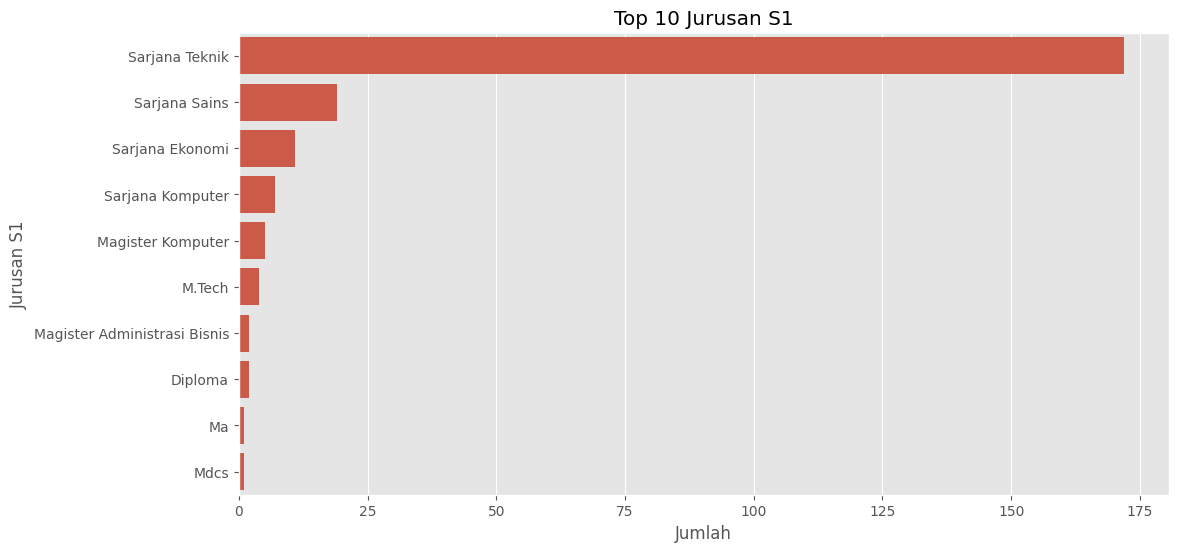

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_major.values,
    y=top_major.index
)
plt.title("Top 10 Jurusan S1")
plt.xlabel("Jumlah")
plt.ylabel("Jurusan S1")
plt.show()

### Insight Jurusan

Mayoritas pengguna berasal dari jurusan yang berkaitan dengan teknologi dan komputer. Hal ini sesuai dengan fokus project AI Career Navigator yang menargetkan bidang IT dan digital career.

# 8. ANALISIS SKILL

In [19]:
career_df['keterampilan'].head()

0                                    Java; Python; SQL
1    Berpikir Analitis; Berpikir Kritis; Kerja di B...
2                                      C++; HTML; Java
3                                       Tidak Tersedia
4    Berpikir Kritis; Java; Linux; Pemrograman; Pyt...
Name: keterampilan, dtype: str

In [20]:
all_skills = " ".join(career_df['keterampilan'].astype(str)).lower()

import re

skill_list = re.split(r'[,;/\s]+', all_skills)

skill_freq = pd.Series(skill_list).value_counts().head(20)

skill_freq

skills          188
keterampilan    111
berpikir        102
pemrograman      84
sql              81
python           77
knowledge        73
java             65
management       64
komunikasi       57
analitis         51
kritis           51
problem          47
solving          47
kerja            44
business         42
mendengarkan     40
aktif            40
c++              39
data             39
Name: count, dtype: int64

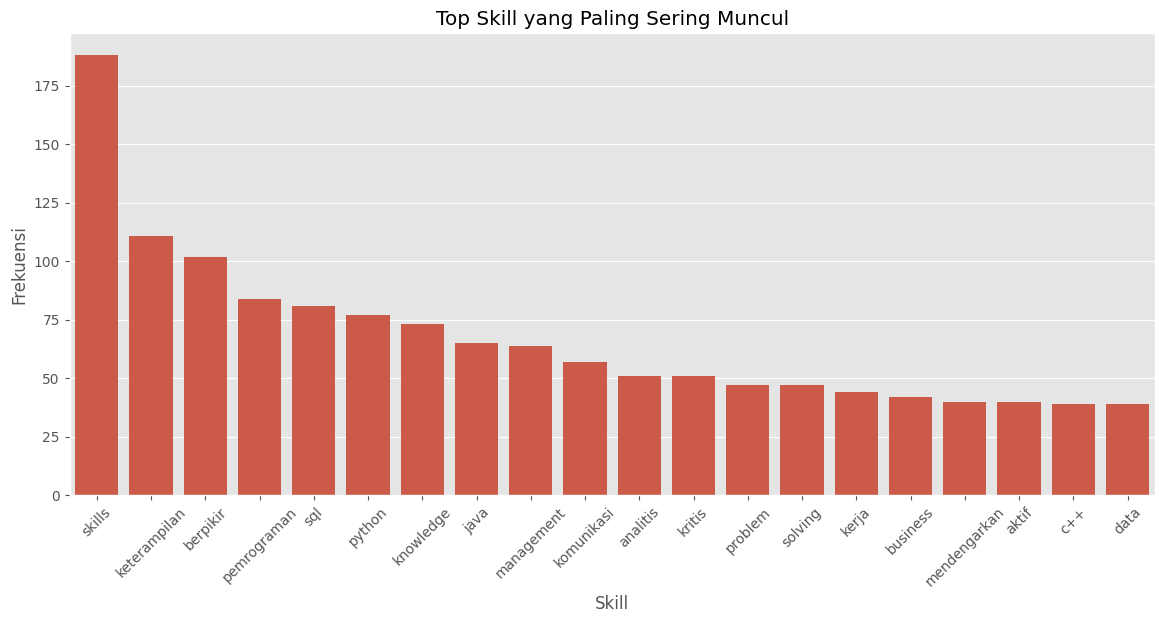

In [21]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=skill_freq.index,
    y=skill_freq.values
)

plt.xticks(rotation=45)

plt.title("Top Skill yang Paling Sering Muncul")
plt.xlabel("Skill")
plt.ylabel("Frekuensi")

plt.show()

### Insight Skill

Skill teknis seperti programming, data analysis, database, dan software development mendominasi dataset. Informasi ini akan menjadi fitur utama pada tahap machine learning untuk memprediksi pekerjaan pengguna.

# 9.JURUSAN VS PEKERJAAN

In [22]:
top_jobs = career_df['pekerjaan_pertama'].value_counts().head(5).index
top_majors = career_df['jurusan_s1'].value_counts().head(5).index

filtered_df = career_df[
    career_df['pekerjaan_pertama'].isin(top_jobs) &
    career_df['jurusan_s1'].isin(top_majors)
]

In [23]:
cross_tab = pd.crosstab(
    filtered_df['jurusan_s1'],
    filtered_df['pekerjaan_pertama']
)

cross_tab

pekerjaan_pertama,Associate Consultant,Computer Software Engineer,Data Analyst,Software Developer,Software Engineer
jurusan_s1,,,,,
Sarjana Ekonomi,0,1,0,0,0
Sarjana Sains,0,2,1,0,0
Sarjana Teknik,8,9,8,8,9


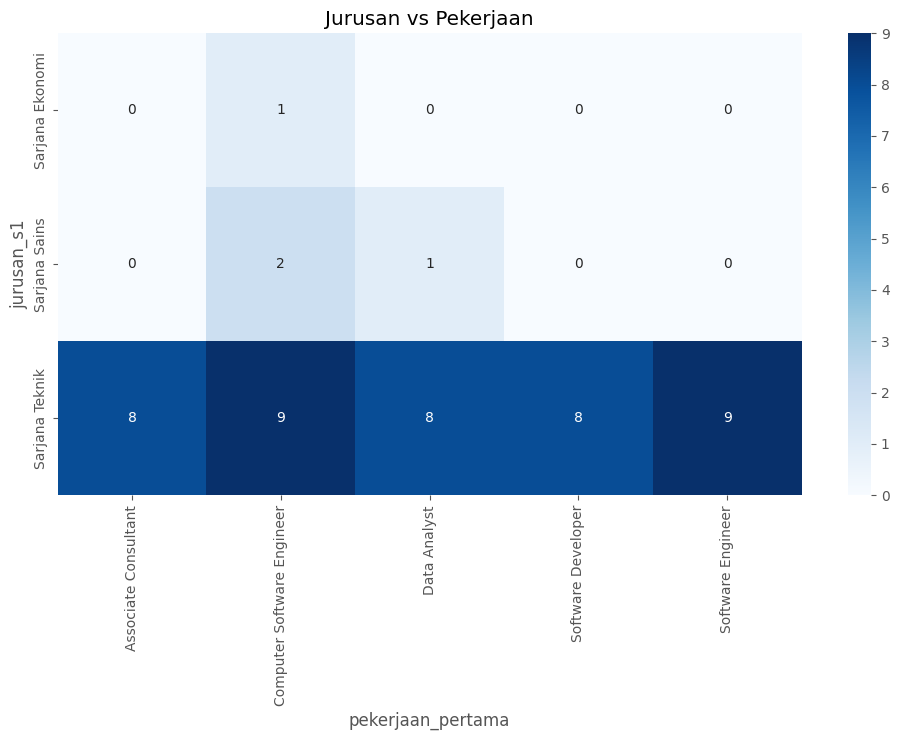

In [24]:
plt.figure(figsize=(12,6))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Jurusan vs Pekerjaan")
plt.show()

### Insight Jurusan vs Pekerjaan

Beberapa jurusan memiliki kecenderungan terhadap pekerjaan tertentu di bidang IT. Namun demikian, distribusi pekerjaan tetap dipengaruhi oleh keterampilan dan pengalaman yang dimiliki pengguna.

# 10. SERTIFIKASI VS PEKERJAAN

In [25]:
career_df[['judul_sertifikasi', 'pekerjaan_pertama']].head()

,judul_sertifikasi,pekerjaan_pertama
0,"Linux,Git",Software
1,Microsoft Certification,Computer Software Engineer
2,"C,C++,Html,Java",Analis Jaringan
3,No,Software Engineer Trainee
4,Redhat Certification,Senior Software Engineer


In [26]:
filtered_cert = career_df[
    career_df['judul_sertifikasi'] != 'No'
]

top_cert = filtered_cert['judul_sertifikasi'] \
    .value_counts() \
    .head(10)

top_cert

judul_sertifikasi
Data Science               3
Digital Marketing          2
Sql                        2
Python Programming         2
Data Science And Ai        2
Java                       2
Linux,Git                  1
Microsoft Certification    1
C,C++,Html,Java            1
Redhat Certification       1
Name: count, dtype: int64

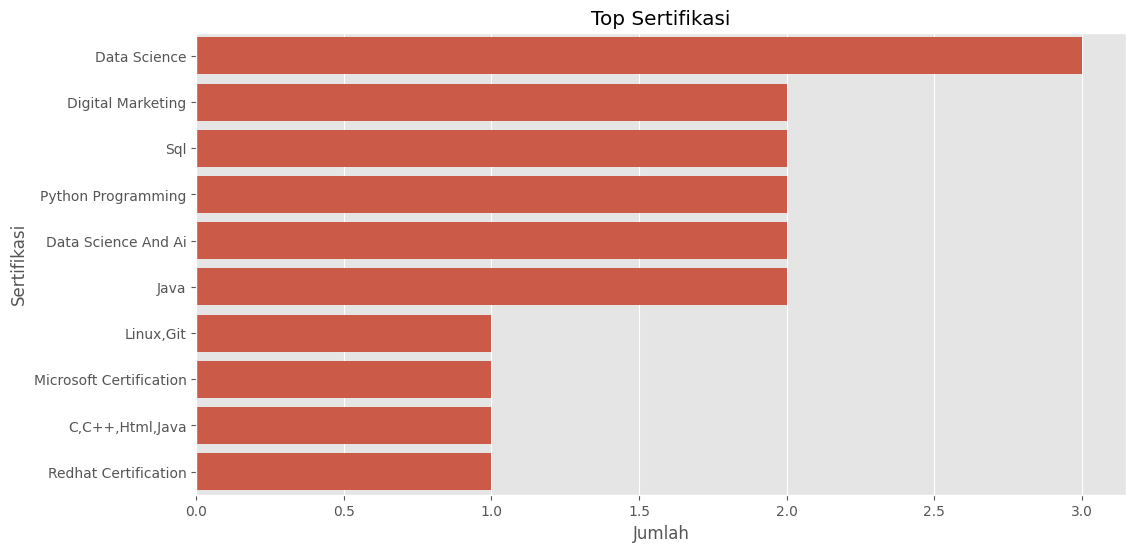

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cert.values,
    y=top_cert.index
)

plt.title("Top Sertifikasi")
plt.xlabel("Jumlah")
plt.ylabel("Sertifikasi")

plt.show()

### Insight Sertifikasi

Sertifikasi teknis memiliki kontribusi dalam mendukung kesiapan karir pengguna. Informasi sertifikasi dapat dikembangkan menjadi fitur tambahan pada model rekomendasi karir di tahap lanjutan.

Pada kolom sertifikasi ditemukan banyak pengguna yang belum memiliki sertifikasi (“No”). Data tersebut tetap dipertahankan pada tahap modeling karena masih merepresentasikan kondisi pengguna secara valid. Namun pada tahap visualisasi EDA, label “No” difilter agar insight sertifikasi teknis lebih mudah dianalisis.

# 11. DATA DICTIONARY

In [28]:
data_dict = pd.DataFrame({
    "Kolom": career_df.columns,
    "Deskripsi": [
        "Jenis kelamin pengguna",
        "Jurusan S1 pengguna",
        "Spesialisasi bidang studi",
        "Minat pengguna",
        "Keterampilan teknis pengguna",
        "Judul sertifikasi yang dimiliki",
        "Pekerjaan pertama pengguna",
        "Nilai IPK pengguna",
        "Gabungan seluruh profil pengguna"
    ]
})

data_dict

,Kolom,Deskripsi
0,jenis_kelamin,Jenis kelamin pengguna
1,jurusan_s1,Jurusan S1 pengguna
2,spesialisasi_s1,Spesialisasi bidang studi
3,minat,Minat pengguna
4,keterampilan,Keterampilan teknis pengguna
5,judul_sertifikasi,Judul sertifikasi yang dimiliki
6,pekerjaan_pertama,Pekerjaan pertama pengguna
7,ipk_s1,Nilai IPK pengguna
8,profil_lengkap,Gabungan seluruh profil pengguna


# 12. KESIMPULAN EDA
### Kesimpulan EDA

Berdasarkan hasil eksplorasi data, dataset career IT recommendation memiliki kualitas data yang cukup baik dan relevan untuk membangun sistem AI Career Navigator. Variabel keterampilan (`keterampilan`) menjadi fitur utama yang paling berpengaruh dalam proses klasifikasi pekerjaan (`pekerjaan_pertama`).

Selain itu, faktor jurusan, sertifikasi, dan minat pengguna juga menunjukkan hubungan terhadap distribusi karir di bidang IT. Dataset ini selanjutnya akan digunakan pada tahap preprocessing NLP dan baseline modeling menggunakan TensorFlow.